# Customer Clustering with Machine Learning

# Retail Data Warehouse V2

This notebook uses unsupervised machine learning to identify natural customer groups based on RFM behavior.

In [65]:
import pandas as pd

In [66]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
from sklearn.cluster import KMeans

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
df = pd.read_csv("../retail_sales.csv")
df.head()

,sale_id,sale_date,customer_id,product,category,quantity,price,store_id,payment_method
0,10001,2025-05-28,C1616,Keyboard,Accessories,5,49.99,S005,Mobile Payment
1,10002,2024-08-06,C1284,Laptop,Computers,3,899.99,S001,Cash
2,10003,2025-10-19,C0297,Laptop,Computers,1,899.99,S003,Credit Card
3,10004,2024-07-09,C1438,Webcam,Electronics,5,79.99,S005,Cash
4,10005,2025-05-24,C1743,Webcam,Electronics,4,79.99,S004,Cash


In [70]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

In [71]:
latest_sale_date = df["sale_date"].max()

analysis_date = latest_sale_date + pd.Timedelta(days=1)

analysis_date

Timestamp('2026-01-01 00:00:00')

In [72]:
latest_sale_date = df["sale_date"].max()

analysis_date = latest_sale_date + pd.Timedelta(days=1)

analysis_date

Timestamp('2026-01-01 00:00:00')

In [73]:
df["total_sales"] = df["quantity"] * df["price"]

In [74]:
rfm = (
    df.groupby("customer_id")
    .agg(
        last_purchase=("sale_date", "max"), 
        frequency=("sale_id", "count"),
        monetary=("total_sales", "sum")
    )
)

In [75]:
rfm.head()

,last_purchase,frequency,monetary
customer_id,,,
C0001,2025-11-18,28,12149.29
C0002,2025-12-06,25,14889.33
C0003,2025-12-05,25,9694.21
C0004,2025-11-12,24,7164.35
C0005,2025-12-25,25,11209.26


In [76]:
rfm["recency"] = (
    analysis_date - rfm["last_purchase"]
).dt.days

In [77]:
rfm.head()

,last_purchase,frequency,monetary,recency
customer_id,,,,
C0001,2025-11-18,28,12149.29,44
C0002,2025-12-06,25,14889.33,26
C0003,2025-12-05,25,9694.21,27
C0004,2025-11-12,24,7164.35,50
C0005,2025-12-25,25,11209.26,7


In [78]:
rfm_analysis = rfm[
    ["recency", "frequency", "monetary"]
].copy()

rfm_analysis.head()

,recency,frequency,monetary
customer_id,,,
C0001,44,28,12149.29
C0002,26,25,14889.33
C0003,27,25,9694.21
C0004,50,24,7164.35
C0005,7,25,11209.26


In [79]:
scaler = StandardScaler()

In [80]:
rfm_scaled = scaler.fit_transform(rfm_analysis)

In [81]:
rfm_scaled[:5]

array([[ 0.49405058,  0.58463872,  0.03245061],
       [-0.12887674,  0.        ,  0.57604128],
       [-0.09426967,  0.        , -0.45460745],
       [ 0.70169301, -0.19487957, -0.95650096],
       [-0.78641113,  0.        , -0.15403993]])

In [82]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["recency", "frequency", "monetary"],
    index=rfm_analysis.index
)

rfm_scaled_df.head()

,recency,frequency,monetary
customer_id,,,
C0001,0.494051,0.584639,0.032451
C0002,-0.128877,0.000000,0.576041
C0003,-0.094270,0.000000,-0.454607
C0004,0.701693,-0.194880,-0.956501
C0005,-0.786411,0.000000,-0.154040


In [83]:
inertia = []

In [84]:
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)

In [85]:
    model.fit(rfm_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](10, 3)",

In [86]:
inertia = []

In [87]:
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

In [88]:
len(inertia)

10

In [89]:
inertia

[6000.0,
 3971.647270446249,
 2926.2940649393568,
 2432.664516682458,
 2121.5610316977936,
 1931.8187718989932,
 1791.8576520589013,
 1592.6609928054465,
 1511.4787298346596,
 1413.0704728526389]

In [90]:
import matplotlib.pyplot as plt

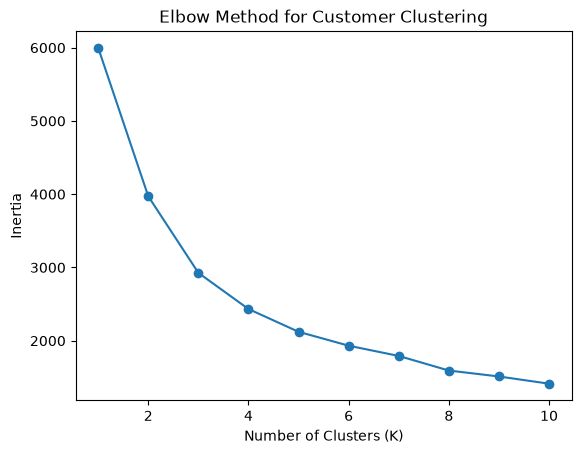

In [91]:
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Clustering")
plt.savefig("../../images/11_machine_learning/elbow_method.png")

In [92]:
len(inertia)

10

In [93]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [94]:
kmeans.fit(rfm_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 3)","[

In [95]:
kmeans.labels_

array([1, 1, 2, ..., 2, 2, 1], shape=(2000,), dtype=int32)

In [96]:
rfm_analysis["cluster"] = kmeans.labels_

In [97]:
rfm_analysis.head()

,recency,frequency,monetary,cluster
customer_id,,,,
C0001,44,28,12149.29,1
C0002,26,25,14889.33,1
C0003,27,25,9694.21,2
C0004,50,24,7164.35,2
C0005,7,25,11209.26,2


In [98]:
rfm_analysis["cluster"].value_counts()

cluster
2    943
1    782
0    275
Name: count, dtype: int64

In [99]:
cluster_profile = rfm_analysis.groupby("cluster").mean()

In [100]:
cluster_profile

,recency,frequency,monetary
cluster,,,
0,86.400000,22.240000,10206.429091
1,20.604859,29.312020,16268.960524
2,20.758218,22.229056,8952.642386


In [101]:
cluster_profile_scaled = scaler.transform(cluster_profile)

In [102]:
cluster_profile_scaled

array([[ 1.96139047, -0.53786763, -0.3529894 ],
       [-0.31558677,  0.84032471,  0.84974322],
       [-0.31027946, -0.54000035, -0.60172546]])

In [103]:
cluster_profile_scaled_df = pd.DataFrame(
    cluster_profile_scaled,
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

In [104]:
cluster_profile_scaled_df

,recency,frequency,monetary
cluster,,,
0,1.961390,-0.537868,-0.352989
1,-0.315587,0.840325,0.849743
2,-0.310279,-0.540000,-0.601725


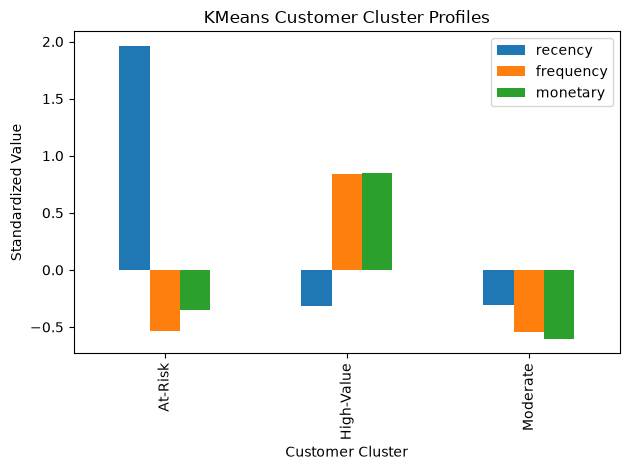

In [124]:
cluster_profile_scaled_df.plot(kind="bar")
plt.title("KMeans Customer Cluster Profiles")
plt.ylabel("Standardized Value")
plt.xlabel("Customer Cluster")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["At-Risk", "High-Value", "Moderate"]
)
plt.tight_layout()
plt.savefig("../../images/11_machine_learning/kmeans_cluster_profiles.png")

In [106]:
import os
os.getcwd()

'c:\\Users\\orlan\\OneDrive\\Documentos\\GitHub\\retail-data-warehouse\\data\\notebooks'

In [107]:
rfm_comparison = rfm_analysis.copy()

In [108]:
rfm_comparison["R_score"] = pd.qcut(
    rfm_comparison["recency"],
    q=4,
    labels=[4, 3, 2, 1]
)

In [109]:
rfm_comparison["F_score"] = pd.qcut(
    rfm_comparison["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
)

In [110]:
rfm_comparison["M_score"] = pd.qcut(
    rfm_comparison["monetary"],
    q=4,
    labels=[1, 2, 3, 4]
)

In [111]:
rfm_comparison.head()

,recency,frequency,monetary,cluster,R_score,F_score,M_score
customer_id,,,,,,,
C0001,44,28,12149.29,1,1,3,3
C0002,26,25,14889.33,1,2,2,3
C0003,27,25,9694.21,2,2,2,2
C0004,50,24,7164.35,2,1,2,1
C0005,7,25,11209.26,2,4,2,2


In [112]:
rfm_comparison["RFM_score"] = (
    rfm_comparison["R_score"].astype(int)
    + rfm_comparison["F_score"].astype(int)
    + rfm_comparison["M_score"].astype(int)
)

In [113]:
def assign_segment(score):
    if score <= 5:
        return "At Risk"
    elif score <= 7:
        return "Developing"
    elif score <= 9:
        return "Loyal"
    else:
        return "Champions"

In [114]:
rfm_comparison["segment"] = rfm_comparison["RFM_score"].apply(assign_segment)

In [115]:
rfm_comparison.head()

,recency,frequency,monetary,cluster,R_score,F_score,M_score,RFM_score,segment
customer_id,,,,,,,,,
C0001,44,28,12149.29,1,1,3,3,7,Developing
C0002,26,25,14889.33,1,2,2,3,7,Developing
C0003,27,25,9694.21,2,2,2,2,6,Developing
C0004,50,24,7164.35,2,1,2,1,4,At Risk
C0005,7,25,11209.26,2,4,2,2,8,Loyal


In [116]:
comparison_table = pd.crosstab(
    rfm_comparison["segment"],
    rfm_comparison["cluster"]
)

In [117]:
comparison_table

cluster,0,1,2
segment,,,
At Risk,167,0,259
Champions,0,432,10
Developing,92,40,417
Loyal,16,310,257


In [118]:
comparison_table.to_numpy().sum()

np.int64(2000)

<Axes: xlabel='segment'>

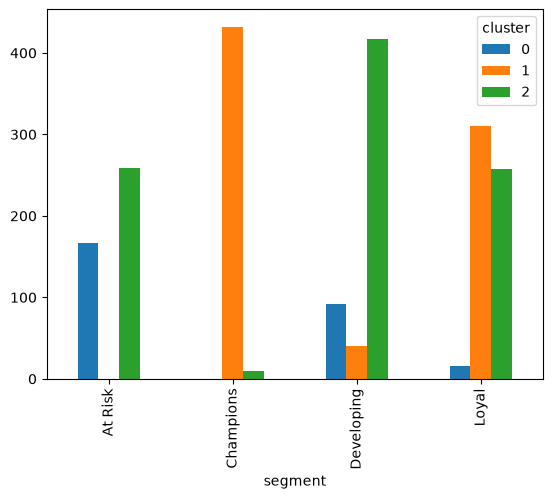

In [119]:
comparison_table.plot(kind="bar")

In [120]:
comparison_chart = comparison_table.rename(
    columns={
        0: "At-Risk / Inactive",
        1: "High-Value",
        2: "Moderate"
    }
)

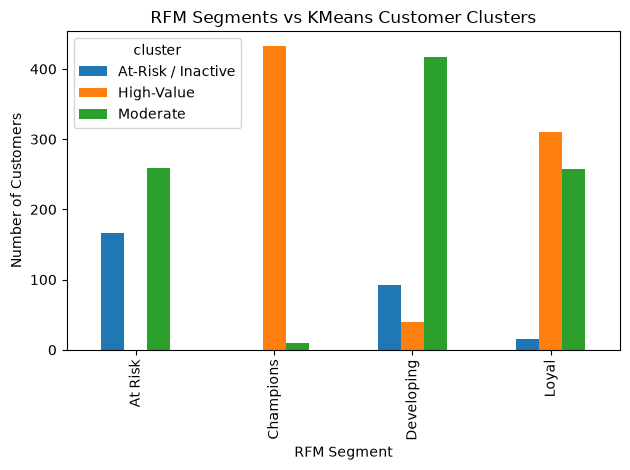

In [123]:
comparison_chart.plot(kind="bar")

plt.title("RFM Segments vs KMeans Customer Clusters")
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("../../images/11_machine_learning/rfm_vs_kmeans.png")

## RFM Segmentation vs KMeans Clustering

This analysis compares traditional rule-based RFM customer segmentation with unsupervised KMeans clustering.

### Why 4 RFM Segments and 3 KMeans Clusters?

The RFM model uses four predefined business segments: **At Risk, Developing, Loyal, and Champions**.

KMeans does not use these business rules. Instead, it groups customers based on similarities in their **Recency, Frequency, and Monetary behavior**.

Using the Elbow Method, three clusters were selected as a reasonable representation of the natural patterns in the customer data.

### KMeans Cluster Interpretation

The three KMeans clusters were interpreted based on their average RFM behavior:

- **Cluster 0 — At-Risk / Inactive:** Customers have the highest recency, meaning they have gone much longer without making a purchase. They also have lower purchase frequency and below-average spending.

- **Cluster 1 — High-Value:** Customers purchase recently and frequently and have the highest monetary value. This represents the strongest customer group discovered by KMeans.

- **Cluster 2 — Moderate:** Customers purchase relatively recently but have lower frequency and monetary value than the High-Value group.

### Comparison Results

The comparison between the rule-based RFM segments and KMeans clusters revealed several important patterns:

- **Champions:** 432 of 442 customers were classified by KMeans as High-Value, showing strong agreement between the two approaches.
- **At Risk:** None of the 426 At Risk customers were classified as High-Value. They were divided between the At-Risk / Inactive and Moderate clusters.
- **Developing:** Most Developing customers (417 of 549) were classified as Moderate.
- **Loyal:** Loyal customers were more divided, with 310 classified as High-Value and 257 as Moderate.

### Conclusion

The RFM and KMeans approaches provide two complementary views of customer behavior.

Rule-based RFM segmentation provides business-defined categories that are easy to interpret and use for customer targeting. KMeans provides a data-driven approach that identifies natural similarities in customer purchasing behavior without relying on predefined segment boundaries.

The results show strong agreement for the highest-value customers, while the Developing and Loyal segments show more overlap across the KMeans clusters. This suggests that machine learning can complement traditional RFM analysis by revealing behavioral patterns that may not be obvious from business rules alone.